In [7]:
import mne 
mne.set_log_level('WARNING')
#makes it so that you don't have to deal with all of the verbose outputs. 

import scipy 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

#can run this in order to stop the verbose outputs from MNE
#mne.set_log_level('WARNING')


In [8]:
import h5py
import numpy as np
import mne

DATA_PATH = '/Users/alexanderspeer/Desktop/eeg-data/lab2-artifact-detection/eeg-data/Exp1_Monopolar_Fz-FC1-FC2-Pz_6x30s_fs256.mat'

# 1. LOAD
with h5py.File(DATA_PATH, 'r') as file:
    eeg = file['y'][:]

if eeg.shape[0] > eeg.shape[1]:
    eeg = eeg.T

time and the sampling rate

In [9]:
time = eeg[0]

fs = int(1 / (np.mean(np.diff(time))))

Getting MNE objects

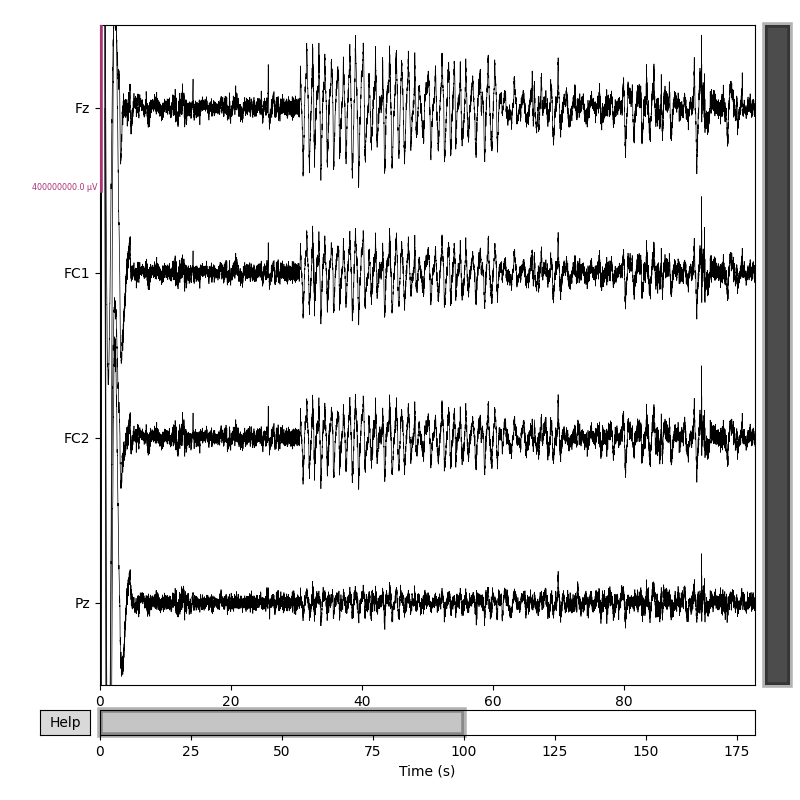

In [10]:
#need to make info and the raw object using the info

channel_names = ['Fz', 'FC1', 'FC2', 'Pz']

info = mne.create_info(
    ch_names = channel_names,
    sfreq = fs,
    ch_types = 'eeg'
)

raw = mne.io.RawArray(eeg[1:], info)

#doing some basic visualization
%matplotlib widget
mne.viz.set_browser_backend('matplotlib')
raw.plot(duration = 100, scalings = dict(eeg = 200));


Doing the winsoring

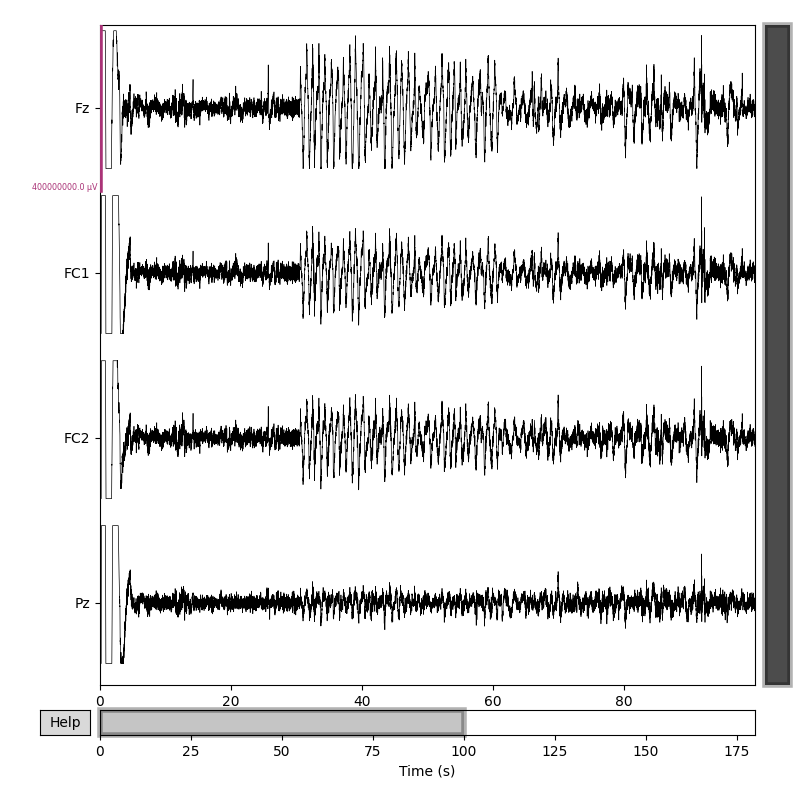

In [11]:

data = raw.get_data()

lower = np.percentile(data, 1)
upper = np.percentile(data, 99)
w_data = np.clip(data, lower, upper)

raw = mne.io.RawArray(w_data, info)

raw.plot(duration = 100, scalings = dict(eeg = 200));


filtering the data

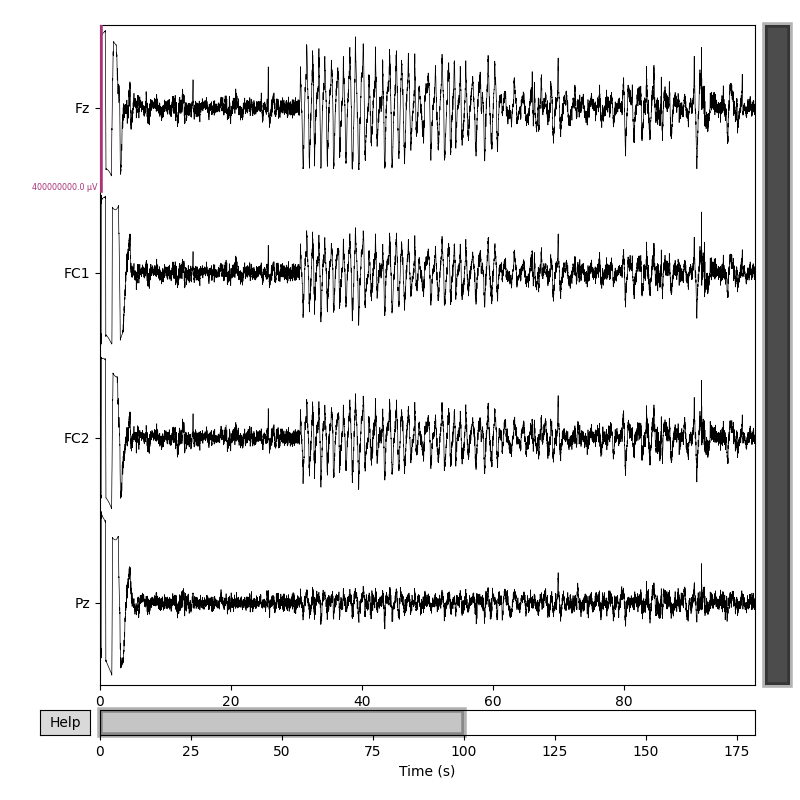

In [12]:
raw.filter(0.5, 40)
raw.notch_filter(60)

raw.plot(duration = 100, scalings = dict(eeg = 200));

Adding a montage for the ensuant artifact rejection

In [18]:
montage = mne.channels.read_custom_montage('../BCI.locs')


raw.set_montage(montage, on_missing='ignore');

#that is recommended.
#if you have a BCI.locs file, that is how you should load it. 

Artifact Rejection

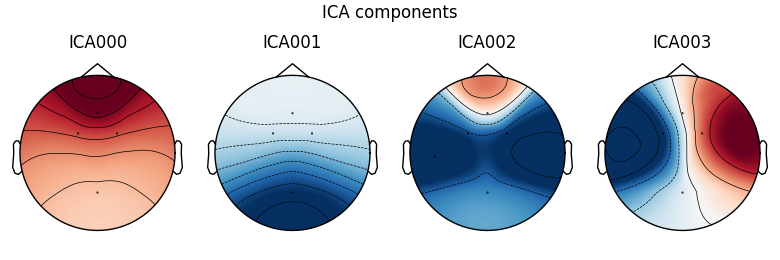

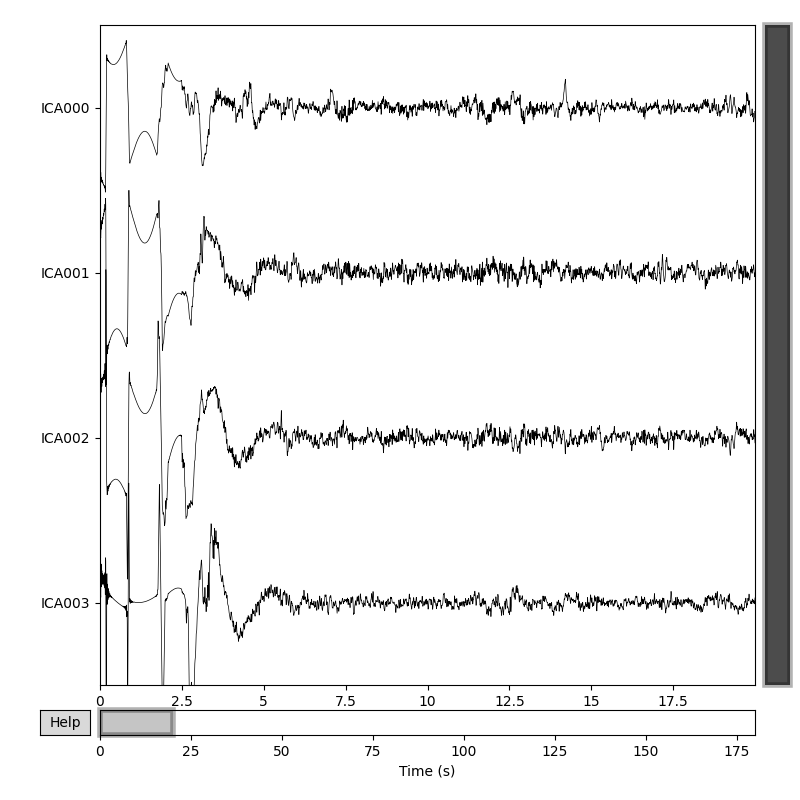

In [ ]:
# Artifact Rejection: ICA with custom BCI.locs montage

from mne.preprocessing import ICA


# 2. Make a copy for ICA fitting
raw_ica = raw.copy()

# 3. ICA usually works better with a high-pass around 1 Hz
raw_ica.filter(l_freq=1, h_freq=40)

# 4. Fit ICA
ica = ICA(
    n_components=4,      # max is number of EEG channels
    random_state=97, #<- only for reproduciblility
    method='fastica'
)

ica.fit(raw_ica)

# 5. Plot ICA scalp maps
ica.plot_components();

# 6. Plot ICA component time courses
ica.plot_sources(raw_ica);

#looking for ICs that appear large right when artifacts appear